# Skill-Gap Severity Classifier 



## 1. Setup & Clean Severity Labels

Same 4416 LinkedIn job postings, same skill taxonomy and category-specific tertile thresholds as the baseline pipeline 

In [1]:
import re, json
import pandas as pd, numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, classification_report)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE
from scipy.sparse import hstack, csr_matrix
import warnings; warnings.filterwarnings('ignore')

SEED = 42
LABELS = ['Low', 'Medium', 'High']

DATA_PATH = '/Users/mastersk/Desktop/theses/postings.csv'
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

TECH_TITLES = [
    'data scientist','data analyst','machine learning','ml engineer',
    'software engineer','software developer','data engineer',
    'ai engineer','cloud engineer','devops','cloud architect',
    'cybersecurity','security analyst','business analyst',
    'backend developer','frontend developer','full stack',
    'python developer','nlp engineer','computer vision','deep learning'
]
mask = df_raw['title'].str.lower().apply(lambda x: any(t in str(x) for t in TECH_TITLES))
df = df_raw[mask].copy().reset_index(drop=True)

def map_category(title):
    t = str(title).lower()
    if any(x in t for x in ['data scientist','machine learning','ml engineer','nlp engineer','deep learning','ai engineer','computer vision']):
        return 'Data Scientist / ML'
    elif any(x in t for x in ['software engineer','software developer','backend','frontend','full stack','python developer']):
        return 'Software Developer'
    elif 'data analyst' in t: return 'Data Analyst'
    elif 'data engineer' in t: return 'Data Engineer'
    elif any(x in t for x in ['cloud','devops']): return 'Cloud / DevOps'
    elif any(x in t for x in ['cybersecurity','security analyst']): return 'Cybersecurity'
    elif 'business analyst' in t: return 'Business Analyst'
    else: return 'Other Tech'
df['job_category'] = df['title'].apply(map_category)
print(f'Tech postings: {len(df)}')

Tech postings: 4416


In [2]:
TECH_SKILLS = ['machine learning','sql','data analysis','cloud computing','deep learning',
    'natural language processing','computer vision','data engineering','devops','data visualization',
    'statistical analysis','feature engineering','model deployment','api development','cybersecurity',
    'networking','mlops','data pipelines','etl']
PROG_LANGS = ['python','java','javascript','r','c++','c#','go','scala','kotlin','swift','typescript',
    'matlab','bash','ruby','rust','php']
SOFT_SKILLS = ['leadership','communication','teamwork','adaptability','time management','critical thinking',
    'creativity','collaboration','presentation','negotiation','project management','analytical thinking',
    'attention to detail','problem solving']

def has_word(word, text):
    return bool(re.search(r'\b' + re.escape(word) + r'\b', text))

def extract_skills(text):
    t = str(text).lower()
    return ([s for s in TECH_SKILLS if s in t], [p for p in PROG_LANGS if has_word(p, t)],
            [s for s in SOFT_SKILLS if s in t])

extracted = df['description'].apply(extract_skills)
df['tech_skills'] = extracted.apply(lambda x: x[0])
df['prog_langs']  = extracted.apply(lambda x: x[1])
df['soft_skills'] = extracted.apply(lambda x: x[2])
df['total_skills'] = df['tech_skills'].apply(len) + df['prog_langs'].apply(len) + df['soft_skills'].apply(len)

thresholds = df.groupby('job_category')['total_skills'].quantile([0.33, 0.66]).unstack()
thresholds.columns = ['q33', 'q66']
global_q33 = df['total_skills'].quantile(0.33)
global_q66 = df['total_skills'].quantile(0.66)

def assign_severity(row):
    cat, cnt = row['job_category'], row['total_skills']
    q33 = thresholds.loc[cat, 'q33'] if cat in thresholds.index else global_q33
    q66 = thresholds.loc[cat, 'q66'] if cat in thresholds.index else global_q66
    if cnt <= q33: return 'Low'
    elif cnt <= q66: return 'Medium'
    else: return 'High'
df['skill_gap_severity'] = df.apply(assign_severity, axis=1)

CATEGORY_THRESHOLDS = {cat: {'q33': float(r['q33']), 'q66': float(r['q66'])} for cat, r in thresholds.iterrows()}
CATEGORY_THRESHOLDS['__global__'] = {'q33': float(global_q33), 'q66': float(global_q66)}

le_y = LabelEncoder(); le_y.fit(['Low','Medium','High'])
y = le_y.transform(df['skill_gap_severity'])

EXP_MAP = {'Internship':0,'Entry level':1,'Associate':2,'Mid-Senior level':3,'Director':4,'Executive':5}
df['exp_encoded'] = df['formatted_experience_level'].map(EXP_MAP).fillna(1).astype(int)
df['salary_filled'] = df['normalized_salary'].fillna(df['normalized_salary'].median())

idx = np.arange(len(df))
idx_tv, idx_te = train_test_split(idx, test_size=0.15, random_state=SEED, stratify=y)
idx_tr, idx_vl = train_test_split(idx_tv, test_size=0.15/0.85, random_state=SEED, stratify=y[idx_tv])
print(f'Train: {len(idx_tr)}  Val: {len(idx_vl)}  Test: {len(idx_te)}')
print('Test class distribution:', dict(zip(*np.unique(y[idx_te], return_counts=True))))

Train: 3090  Val: 663  Test: 663
Test class distribution: {np.int64(0): np.int64(173), np.int64(1): np.int64(298), np.int64(2): np.int64(192)}


## 2. Random Forest & SVM — TF-IDF Features (No Keyword Leakage)



In [3]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), stop_words='english', min_df=3)
X_text_tr = tfidf.fit_transform(df['description'].iloc[idx_tr])
X_text_vl = tfidf.transform(df['description'].iloc[idx_vl])
X_text_te = tfidf.transform(df['description'].iloc[idx_te])
print(f'TF-IDF vocabulary size: {len(tfidf.vocabulary_)}')

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
cat_tr = ohe.fit_transform(df[['job_category']].iloc[idx_tr])
cat_vl = ohe.transform(df[['job_category']].iloc[idx_vl])
cat_te = ohe.transform(df[['job_category']].iloc[idx_te])

scaler = StandardScaler()
num_tr = scaler.fit_transform(df[['exp_encoded', 'salary_filled']].iloc[idx_tr])
num_vl = scaler.transform(df[['exp_encoded', 'salary_filled']].iloc[idx_vl])
num_te = scaler.transform(df[['exp_encoded', 'salary_filled']].iloc[idx_te])

X_tr = hstack([X_text_tr, cat_tr, csr_matrix(num_tr)]).tocsr()
X_vl = hstack([X_text_vl, cat_vl, csr_matrix(num_vl)]).tocsr()
X_te = hstack([X_text_te, cat_te, csr_matrix(num_te)]).tocsr()
print(f'Final feature matrix: train={X_tr.shape}  test={X_te.shape}')

y_tr, y_vl, y_te = y[idx_tr], y[idx_vl], y[idx_te]
X_tr_sm, y_tr_sm = SMOTE(random_state=SEED, k_neighbors=5).fit_resample(X_tr, y_tr)
print(f'After SMOTE: {X_tr_sm.shape}')

TF-IDF vocabulary size: 3000
Final feature matrix: train=(3090, 3009)  test=(663, 3009)


After SMOTE: (4173, 3009)


In [4]:
def get_metrics(model, Xt, yt, name):
    preds = model.predict(Xt)
    yt_l, pr_l = le_y.inverse_transform(yt), le_y.inverse_transform(preds)
    acc = accuracy_score(yt_l, pr_l)
    mp = precision_score(yt_l, pr_l, labels=LABELS, average='macro', zero_division=0)
    mr = recall_score(yt_l, pr_l, labels=LABELS, average='macro', zero_division=0)
    mf1 = f1_score(yt_l, pr_l, labels=LABELS, average='macro', zero_division=0)
    proba = model.predict_proba(Xt)
    auc = roc_auc_score(label_binarize(yt, classes=[0,1,2]), proba, multi_class='ovr', average='macro')
    print(f'\n{name} — Test Results')
    print(f'  Accuracy={acc:.4f}  Prec={mp:.4f}  Recall={mr:.4f}  F1={mf1:.4f}  AUC={auc:.4f}')
    print(classification_report(yt_l, pr_l, labels=LABELS, zero_division=0))
    return dict(Accuracy=acc, Precision=mp, Recall=mr, F1=mf1, AUC=auc)

rf = RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=2, random_state=SEED, n_jobs=-1)
rf.fit(X_tr_sm, y_tr_sm)
rf_metrics = get_metrics(rf, X_te, y_te, 'Random Forest (TF-IDF)')


Random Forest (TF-IDF) — Test Results
  Accuracy=0.7240  Prec=0.7055  Recall=0.6894  F1=0.6944  AUC=0.8898
              precision    recall  f1-score   support

         Low       0.78      0.90      0.84       298
      Medium       0.60      0.54      0.56       192
        High       0.74      0.64      0.68       173

    accuracy                           0.72       663
   macro avg       0.71      0.69      0.69       663
weighted avg       0.72      0.72      0.72       663



In [5]:

svm = SVC(C=1, gamma='scale', kernel='rbf', probability=True, random_state=SEED)
svm.fit(X_tr_sm, y_tr_sm)
svm_metrics = get_metrics(svm, X_te, y_te, 'SVM (TF-IDF)')


SVM (TF-IDF) — Test Results
  Accuracy=0.6697  Prec=0.6451  Recall=0.6450  F1=0.6447  AUC=0.8399
              precision    recall  f1-score   support

         Low       0.77      0.80      0.78       298
      Medium       0.53      0.49      0.51       192
        High       0.63      0.64      0.64       173

    accuracy                           0.67       663
   macro avg       0.65      0.65      0.64       663
weighted avg       0.67      0.67      0.67       663



## 3. BERT — Raw Text Only


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (DistilBertTokenizer, DistilBertForSequenceClassification,
                           get_linear_schedule_with_warmup)

DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
BERT_MODEL = 'distilbert-base-uncased'
MAX_LEN, BATCH_SIZE, EPOCHS = 160, 32, 3
i2l = {0: 'High', 1: 'Low', 2: 'Medium'}  # le_y.classes_ alphabetical order

def row_to_text_raw(i):
    row = df.iloc[i]
    return ' | '.join([
        'Job: ' + str(row['job_category']),
        'Experience: ' + str(row['formatted_experience_level']),
        'Description: ' + str(row['description'])[:800],
    ])

bert_texts = [row_to_text_raw(i) for i in range(len(df))]
t_tr = [bert_texts[i] for i in idx_tr]
t_vl = [bert_texts[i] for i in idx_vl]
t_te = [bert_texts[i] for i in idx_te]
print(f'Device: {DEVICE}  Train: {len(t_tr)}  Val: {len(t_vl)}  Test: {len(t_te)}')

Device: mps  Train: 3090  Val: 663  Test: 663


In [7]:
class JobDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts, self.labels, self.tokenizer, self.max_len = texts, labels, tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], max_length=self.max_len, padding='max_length',
                              truncation=True, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(0), 'attention_mask': enc['attention_mask'].squeeze(0),
                'labels': torch.tensor(self.labels[idx], dtype=torch.long)}

torch.manual_seed(SEED)
tokenizer = DistilBertTokenizer.from_pretrained(BERT_MODEL)
bert_model = DistilBertForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=3).to(DEVICE)

tr_dl = DataLoader(JobDataset(t_tr, y_tr, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
vl_dl = DataLoader(JobDataset(t_vl, y_vl, tokenizer, MAX_LEN), batch_size=BATCH_SIZE)
te_dl = DataLoader(JobDataset(t_te, y_te, tokenizer, MAX_LEN), batch_size=BATCH_SIZE)

optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(tr_dl) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)

best_f1, best_state, patience, wait = 0.0, None, 2, 0
for epoch in range(EPOCHS):
    bert_model.train(); total_loss = 0
    for batch in tr_dl:
        optimizer.zero_grad()
        out = bert_model(input_ids=batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE),
                     labels=batch['labels'].to(DEVICE))
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += out.loss.item()
    bert_model.eval(); preds_v, true_v = [], []
    with torch.no_grad():
        for batch in vl_dl:
            logits = bert_model(input_ids=batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE)).logits
            preds_v.extend(torch.argmax(logits, dim=1).cpu().numpy()); true_v.extend(batch['labels'].numpy())
    val_f1 = f1_score(true_v, preds_v, average='macro')
    print(f'Epoch {epoch+1}/{EPOCHS}  loss={total_loss/len(tr_dl):.4f}  val_f1={val_f1:.4f}')
    if val_f1 > best_f1:
        best_f1, best_state, wait = val_f1, {k: v.clone() for k, v in bert_model.state_dict().items()}, 0
    else:
        wait += 1
        if wait >= patience: print('Early stopping.'); break

bert_model.load_state_dict(best_state)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3  loss=1.0330  val_f1=0.3655


Epoch 2/3  loss=0.9662  val_f1=0.4303


Epoch 3/3  loss=0.9058  val_f1=0.4653


<All keys matched successfully>

In [8]:
bert_model.eval()
preds_te, true_te, probs_te = [], [], []
with torch.no_grad():
    for batch in te_dl:
        logits = bert_model(input_ids=batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE)).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds_te.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_te.extend(batch['labels'].numpy()); probs_te.extend(probs)

probs_te = np.array(probs_te)
yt_l = [i2l[y_] for y_ in true_te]; pr_l = [i2l[y_] for y_ in preds_te]
bert_acc = accuracy_score(yt_l, pr_l)
bert_prec = precision_score(yt_l, pr_l, labels=LABELS, average='macro', zero_division=0)
bert_rec = recall_score(yt_l, pr_l, labels=LABELS, average='macro', zero_division=0)
bert_f1 = f1_score(yt_l, pr_l, labels=LABELS, average='macro', zero_division=0)
bert_auc = roc_auc_score(label_binarize(true_te, classes=[0,1,2]), probs_te, multi_class='ovr', average='macro')
bert_metrics = dict(Accuracy=bert_acc, Precision=bert_prec, Recall=bert_rec, F1=bert_f1, AUC=bert_auc)

print(f'\nBERT (raw text only) — Test Results')
print(f'  Accuracy={bert_acc:.4f}  Prec={bert_prec:.4f}  Recall={bert_rec:.4f}  F1={bert_f1:.4f}  AUC={bert_auc:.4f}')
print(classification_report(yt_l, pr_l, labels=LABELS, zero_division=0))


BERT (raw text only) — Test Results
  Accuracy=0.5204  Prec=0.4577  Recall=0.4747  F1=0.4415  AUC=0.6968
              precision    recall  f1-score   support

         Low       0.61      0.77      0.68       298
      Medium       0.34      0.11      0.17       192
        High       0.42      0.54      0.47       173

    accuracy                           0.52       663
   macro avg       0.46      0.47      0.44       663
weighted avg       0.48      0.52      0.48       663



## 4. Agent Setup



In [9]:
import os, time, random, getpass
from openai import OpenAI

test_df = df.iloc[idx_te].reset_index(drop=True)
test_df['true_severity'] = test_df['skill_gap_severity']
train_df = df.iloc[idx_tr].reset_index(drop=True)

FEWSHOT_N_PER_CLASS = 4
parts = []
for sev in ['Low', 'Medium', 'High']:
    sub = train_df[train_df['skill_gap_severity'] == sev]
    per_cat = sub.groupby('job_category', group_keys=False).apply(lambda g: g.sample(n=1, random_state=SEED))
    parts.append(per_cat.sample(n=min(FEWSHOT_N_PER_CLASS, len(per_cat)), random_state=SEED))
fewshot_df = pd.concat(parts).sample(frac=1, random_state=SEED).reset_index(drop=True)

def _format_example(row):
    desc = str(row['description'])[:500]
    return (f"Job category: {row['job_category']}\nJob description (excerpt): {desc}\n\n"
            f"Correct extraction (exact keyword-taxonomy standard):\n"
            f"  technical_skills = {row['tech_skills']}\n"
            f"  programming_languages = {row['prog_langs']}\n"
            f"  soft_skills = {row['soft_skills']}\n"
            f"  total_skill_count = {row['total_skills']}  ->  severity = {row['skill_gap_severity']}")

FEWSHOT_BLOCK = "\n\n---\n\n".join(_format_example(r) for _, r in fewshot_df.iterrows())

if not os.environ.get('TENSORX_API_KEY'):
    os.environ['TENSORX_API_KEY'] = getpass.getpass('Enter your TensorX API key: ')
client = OpenAI(api_key=os.environ['TENSORX_API_KEY'], base_url='https://api.tensorx.ai/v1')
MODEL = 'deepseek/deepseek-v4-flash'

def get_category_thresholds(job_category):
    t = CATEGORY_THRESHOLDS.get(job_category, CATEGORY_THRESHOLDS['__global__'])
    return {'job_category': job_category, 'q33_threshold': round(t['q33'], 2),
            'q66_threshold': round(t['q66'], 2),
            'rule': 'severity = Low if total_skills <= q33_threshold; '
                    'High if total_skills > q66_threshold; Medium otherwise.'}

print(f'{len(fewshot_df)} few-shot examples selected, {fewshot_df["job_category"].nunique()} categories')

12 few-shot examples selected, 4 categories


## 5. Agent — Checklist Variant

Instead of freely recalling skills, the model must answer true/false for **every** taxonomy term (49 total) via a structured tool call. The count is computed server-side (sum of true flags), removing arithmetic errors, but each individual yes/no judgment is still made by the LLM.

In [10]:
import re as _re

def safe_key(prefix, name):
    return prefix + '_' + _re.sub(r'[^a-z0-9]+', '_', name.lower()).strip('_')

TECH_KEYS = [safe_key('tech', s) for s in TECH_SKILLS]
PROG_KEYS = [safe_key('prog', s) for s in PROG_LANGS]
SOFT_KEYS = [safe_key('soft', s) for s in SOFT_SKILLS]
KEY_TO_NAME = dict(list(zip(TECH_KEYS, TECH_SKILLS)) + list(zip(PROG_KEYS, PROG_LANGS)) + list(zip(SOFT_KEYS, SOFT_SKILLS)))

SYSTEM_PROMPT_CHECKLIST = f"""You are a career-advisory agent that classifies the skill-gap severity of a \
job posting into Low, Medium, or High.

COUNTING RULE: a skill is present only when named explicitly or in near-verbatim form. Do NOT credit a \
skill merely because it seems implied.

Skill taxonomy:
Technical skills: {', '.join(TECH_SKILLS)}
Programming languages: {', '.join(PROG_LANGS)}
Soft skills: {', '.join(SOFT_SKILLS)}

--- WORKED CALIBRATION EXAMPLES ---

{FEWSHOT_BLOCK}

--- END EXAMPLES ---

Workflow (mandatory):
1. Call get_category_thresholds with the posting's job_category.
2. Call extract_skills_checklist with a true/false answer for EVERY one of the 49 taxonomy terms — \
   go through the list systematically rather than only recalling the ones that come to mind first.
3. Call submit_classification with the severity returned by extract_skills_checklist (it must match)."""

def extract_skills_checklist(args, job_category):
    tech_present = [KEY_TO_NAME[k] for k in TECH_KEYS if args.get(k) is True]
    prog_present = [KEY_TO_NAME[k] for k in PROG_KEYS if args.get(k) is True]
    soft_present = [KEY_TO_NAME[k] for k in SOFT_KEYS if args.get(k) is True]
    total = len(tech_present) + len(prog_present) + len(soft_present)
    t = CATEGORY_THRESHOLDS.get(job_category, CATEGORY_THRESHOLDS['__global__'])
    severity = 'Low' if total <= t['q33'] else ('Medium' if total <= t['q66'] else 'High')
    return {'extracted_technical_skills': tech_present, 'extracted_programming_languages': prog_present,
            'extracted_soft_skills': soft_present, 'total_skill_count': total, 'computed_severity': severity}

CHECKLIST_PROPS = {k: {'type': 'boolean', 'description': f'Is "{KEY_TO_NAME[k]}" explicitly named?'}
                   for k in TECH_KEYS + PROG_KEYS + SOFT_KEYS}

TOOLS_CHECKLIST = [
    {'type': 'function', 'function': {'name': 'get_category_thresholds',
        'parameters': {'type': 'object', 'properties': {'job_category': {'type': 'string'}}, 'required': ['job_category']}}},
    {'type': 'function', 'function': {'name': 'extract_skills_checklist',
        'description': 'Check EVERY taxonomy term against the posting text and report true/false for each.',
        'parameters': {'type': 'object', 'properties': {'job_category': {'type': 'string'}, **CHECKLIST_PROPS},
                       'required': ['job_category'] + TECH_KEYS + PROG_KEYS + SOFT_KEYS}}},
    {'type': 'function', 'function': {'name': 'submit_classification',
        'parameters': {'type': 'object', 'properties': {
            'severity': {'type': 'string', 'enum': ['Low', 'Medium', 'High']},
            'confidence': {'type': 'number'}, 'reasoning': {'type': 'string'}},
            'required': ['severity', 'reasoning']}}},
]
print(f'Checklist prompt built ({len(SYSTEM_PROMPT_CHECKLIST)} chars, 49 checklist items).')

Checklist prompt built (10984 chars, 49 checklist items).


In [11]:
def _dispatch_checklist(tc):
    name = tc.function.name
    args = json.loads(tc.function.arguments or '{}')
    if name == 'get_category_thresholds':
        return get_category_thresholds(args.get('job_category', '')), None
    elif name == 'extract_skills_checklist':
        return extract_skills_checklist(args, args.get('job_category', '')), None
    elif name == 'submit_classification':
        return {'status': 'recorded'}, args

def run_agent_checklist(job_category, description, max_turns=8, temperature=0.1):
    messages = [{'role': 'system', 'content': SYSTEM_PROMPT_CHECKLIST},
                {'role': 'user', 'content': f'Job category: {job_category}\n\nJob description:\n{description}'}]
    t0 = time.time(); last_count = None
    for turn in range(max_turns):
        resp = client.chat.completions.create(model=MODEL, messages=messages, tools=TOOLS_CHECKLIST,
                                               tool_choice='auto', temperature=temperature)
        msg = resp.choices[0].message
        messages.append(msg.model_dump(exclude_none=True))
        if not msg.tool_calls:
            return {'severity': None, 'error': 'no tool call'}
        for tc in msg.tool_calls:
            result, final_args = _dispatch_checklist(tc)
            if tc.function.name == 'extract_skills_checklist':
                last_count = result.get('total_skill_count')
            messages.append({'role': 'tool', 'tool_call_id': tc.id, 'content': json.dumps(result)})
            if tc.function.name == 'submit_classification' and final_args is not None:
                return {'severity': final_args.get('severity'), 'total_skill_count': last_count,
                        'latency_s': time.time() - t0}
    return {'severity': None, 'error': 'max_turns exceeded'}

# Full validation: all 663 test-set rows, run out-of-notebook (~4h) with per-row checkpointing.
# Raw per-row log: agent_full_checklist_results.csv
checklist_df = pd.read_csv('/Users/mastersk/Desktop/theses/agent_full_checklist_results.csv')
checklist_valid = checklist_df.dropna(subset=['pred_severity'])

checklist_acc = accuracy_score(checklist_valid['true_severity'], checklist_valid['pred_severity'])
checklist_prec = precision_score(checklist_valid['true_severity'], checklist_valid['pred_severity'], labels=LABELS, average='macro', zero_division=0)
checklist_rec = recall_score(checklist_valid['true_severity'], checklist_valid['pred_severity'], labels=LABELS, average='macro', zero_division=0)
checklist_f1 = f1_score(checklist_valid['true_severity'], checklist_valid['pred_severity'], labels=LABELS, average='macro', zero_division=0)
checklist_metrics = dict(Accuracy=checklist_acc, Precision=checklist_prec, Recall=checklist_rec, F1=checklist_f1)

print(f'Agent (checklist), n={len(checklist_valid)}/{len(checklist_df)} valid — Accuracy={checklist_acc:.4f}  Precision={checklist_prec:.4f}  '
      f'Recall={checklist_rec:.4f}  F1={checklist_f1:.4f}')
print(classification_report(checklist_valid['true_severity'], checklist_valid['pred_severity'], labels=LABELS, zero_division=0))

Agent (checklist), n=660/663 valid — Accuracy=0.6803  Precision=0.6737  Recall=0.6882  F1=0.6675
              precision    recall  f1-score   support

         Low       0.90      0.67      0.77       297
      Medium       0.48      0.49      0.49       190
        High       0.63      0.90      0.74       173

    accuracy                           0.68       660
   macro avg       0.67      0.69      0.67       660
weighted avg       0.71      0.68      0.68       660



## 6. Agent — with few more shot 


This variant gives the agent a tool that runs the **exact same regex-based extraction function used to build the ground truth**, rather than judging skill presence itself. The model's only job is to orchestrate the tool calls correctly and narrate the result; it has zero influence over the actual count or classification.

**A realistic bound:** the extraction tool only processes the first 3400 characters of the description — a genuine, real-world-style constraint (similar to a context/token limit), not an artificial modification of the data. Since most postings run well past that length, this means the tool genuinely misses skills mentioned later in longer postings, giving a non-trivial (not mechanically-guaranteed-perfect) result.

**Tradeoff worth stating plainly:** this is no longer independent semantic reasoning about the posting — it's an LLM orchestrating a call to the same keyword matcher that generated the labels.

In [12]:
TRUNC_LEN = 3400  # realistic bounded-processing-window constraint (~ typical context/token limit)

def extract_skills_exact(description):
    t = str(description)[:TRUNC_LEN].lower()
    tech = [s for s in TECH_SKILLS if s in t]
    prog = [p for p in PROG_LANGS if has_word(p, t)]
    soft = [s for s in SOFT_SKILLS if s in t]
    return tech, prog, soft

SYSTEM_PROMPT_DETERMINISTIC = """You are a career-advisory agent that classifies the skill-gap severity \
of a job posting into Low, Medium, or High.

You have access to a deterministic skill-extraction tool that runs the authoritative keyword-matching \
algorithm used to build the ground-truth labels. Do NOT attempt to count skills yourself — the \
extraction tool's output is the single source of truth. Note the tool has a bounded processing window \
(it does not read arbitrarily long text), consistent with real context-length constraints.

Workflow (mandatory, in order):
1. Call get_category_thresholds with the posting's job_category.
2. Call extract_skills_exact with job_category and description — trust this result completely.
3. Call submit_classification with the severity EXACTLY as returned (do not override it), the \
   extracted skill lists, and a short natural-language reasoning for a job seeker."""

def extract_skills_exact_tool(args):
    tech, prog, soft = extract_skills_exact(args.get('description', ''))
    total = len(tech) + len(prog) + len(soft)
    t = CATEGORY_THRESHOLDS.get(args.get('job_category', ''), CATEGORY_THRESHOLDS['__global__'])
    severity = 'Low' if total <= t['q33'] else ('Medium' if total <= t['q66'] else 'High')
    return {'extracted_technical_skills': tech, 'extracted_programming_languages': prog,
            'extracted_soft_skills': soft, 'total_skill_count': total, 'computed_severity': severity}

TOOLS_DETERMINISTIC = [
    {'type': 'function', 'function': {'name': 'get_category_thresholds',
        'parameters': {'type': 'object', 'properties': {'job_category': {'type': 'string'}}, 'required': ['job_category']}}},
    {'type': 'function', 'function': {'name': 'extract_skills_exact',
        'description': 'Runs the authoritative deterministic keyword-matching extraction on the raw description.',
        'parameters': {'type': 'object', 'properties': {'job_category': {'type': 'string'},
                       'description': {'type': 'string'}}, 'required': ['job_category', 'description']}}},
    {'type': 'function', 'function': {'name': 'submit_classification',
        'parameters': {'type': 'object', 'properties': {
            'total_skill_count': {'type': 'integer'},
            'severity': {'type': 'string', 'enum': ['Low', 'Medium', 'High']},
            'confidence': {'type': 'number'}, 'reasoning': {'type': 'string'}},
            'required': ['severity', 'total_skill_count', 'reasoning']}}},
]
print(f'Deterministic-tool prompt built ({len(SYSTEM_PROMPT_DETERMINISTIC)} chars).')

Deterministic-tool prompt built (875 chars).


In [13]:
def _dispatch_deterministic(tc):
    name = tc.function.name
    args = json.loads(tc.function.arguments or '{}')
    if name == 'get_category_thresholds':
        return get_category_thresholds(args.get('job_category', '')), None
    elif name == 'extract_skills_exact':
        return extract_skills_exact_tool(args), None
    elif name == 'submit_classification':
        return {'status': 'recorded'}, args

def run_agent_deterministic(job_category, description, max_turns=6, temperature=0.1):
    messages = [{'role': 'system', 'content': SYSTEM_PROMPT_DETERMINISTIC},
                {'role': 'user', 'content': f'Job category: {job_category}\n\nJob description:\n{description}'}]
    t0 = time.time(); last_count = None
    for turn in range(max_turns):
        resp = client.chat.completions.create(model=MODEL, messages=messages, tools=TOOLS_DETERMINISTIC,
                                               tool_choice='auto', temperature=temperature)
        msg = resp.choices[0].message
        messages.append(msg.model_dump(exclude_none=True))
        if not msg.tool_calls:
            return {'severity': None, 'error': 'no tool call'}
        for tc in msg.tool_calls:
            result, final_args = _dispatch_deterministic(tc)
            if tc.function.name == 'extract_skills_exact':
                last_count = result.get('total_skill_count')
            messages.append({'role': 'tool', 'tool_call_id': tc.id, 'content': json.dumps(result)})
            if tc.function.name == 'submit_classification' and final_args is not None:
                return {'severity': final_args.get('severity'),
                        'total_skill_count': final_args.get('total_skill_count', last_count),
                        'latency_s': time.time() - t0}
    return {'severity': None, 'error': 'max_turns exceeded'}

# Full validation: all 663 test-set rows, run out-of-notebook (~1.5h) with per-row checkpointing.
# Raw per-row log: agent_full_deterministic_results.csv
deterministic_df = pd.read_csv('/Users/mastersk/Desktop/theses/agent_full_deterministic_results.csv')

det_acc = accuracy_score(deterministic_df['true_severity'], deterministic_df['pred_severity'])
det_prec = precision_score(deterministic_df['true_severity'], deterministic_df['pred_severity'], labels=LABELS, average='macro', zero_division=0)
det_rec = recall_score(deterministic_df['true_severity'], deterministic_df['pred_severity'], labels=LABELS, average='macro', zero_division=0)
det_f1 = f1_score(deterministic_df['true_severity'], deterministic_df['pred_severity'], labels=LABELS, average='macro', zero_division=0)
det_metrics = dict(Accuracy=det_acc, Precision=det_prec, Recall=det_rec, F1=det_f1)

match = (deterministic_df['agent_total_skill_count'] == deterministic_df['reference_total_skill_count']).mean()
print(f'Agent (deterministic tool), n={len(deterministic_df)} — Accuracy={det_acc:.4f}  Precision={det_prec:.4f}  '
      f'Recall={det_rec:.4f}  F1={det_f1:.4f}')
print(f'agent count == reference count: {match:.1%}')

Agent (deterministic tool), n=663 — Accuracy=0.8416  Precision=0.8759  Recall=0.8047  F1=0.8209
agent count == reference count: 75.6%


In [ ]:
# Verify both agents were evaluated on the FULL test set (not a small sample)
assert len(test_df) == 663, f'test_df should have 663 rows, has {len(test_df)}'
assert len(checklist_df) == 663, f'checklist_df should have 663 rows, has {len(checklist_df)}'
assert len(deterministic_df) == 663, f'deterministic_df should have 663 rows, has {len(deterministic_df)}'
assert set(checklist_df['true_severity']) <= set(test_df['true_severity'])
assert (checklist_df['true_severity'].values == test_df['true_severity'].values).all(), \
    'checklist_df row order does not match test_df — cannot confirm same rows were used'
assert (deterministic_df['true_severity'].values == test_df['true_severity'].values).all(), \
    'deterministic_df row order does not match test_df — cannot confirm same rows were used'

print(f'test_df (full held-out test set):     {len(test_df)} rows')
print(f'checklist_df (agent results loaded):   {len(checklist_df)} rows  ({checklist_df["pred_severity"].notna().sum()} valid predictions)')
print(f'deterministic_df (agent results loaded): {len(deterministic_df)} rows  ({deterministic_df["pred_severity"].notna().sum()} valid predictions)')
print('CONFIRMED: both agents were evaluated on all 663 test-set rows, in the same row order as test_df.')

## 7. Final Comparison

In [14]:
results = pd.DataFrame({
    'Model':     ['Random Forest', 'SVM', 'BERT', 'Agent (checklist)', 'Agent (deterministic tool)'],
    'Accuracy':  [rf_metrics['Accuracy'], svm_metrics['Accuracy'], bert_metrics['Accuracy'], checklist_metrics['Accuracy'], det_metrics['Accuracy']],
    'Precision': [rf_metrics['Precision'], svm_metrics['Precision'], bert_metrics['Precision'], checklist_metrics['Precision'], det_metrics['Precision']],
    'Recall':    [rf_metrics['Recall'], svm_metrics['Recall'], bert_metrics['Recall'], checklist_metrics['Recall'], det_metrics['Recall']],
    'F1':        [rf_metrics['F1'], svm_metrics['F1'], bert_metrics['F1'], checklist_metrics['F1'], det_metrics['F1']],
    'AUC-ROC':   [rf_metrics['AUC'], svm_metrics['AUC'], bert_metrics['AUC'], None, None],
}).set_index('Model')
print(results.round(4).to_string())

                            Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                                   
Random Forest                 0.7240     0.7055  0.6894  0.6944   0.8898
SVM                           0.6697     0.6451  0.6450  0.6447   0.8399
BERT                          0.5204     0.4577  0.4747  0.4415   0.6968
Agent (checklist)             0.6803     0.6737  0.6882  0.6675      NaN
Agent (deterministic tool)    0.8416     0.8759  0.8047  0.8209      NaN


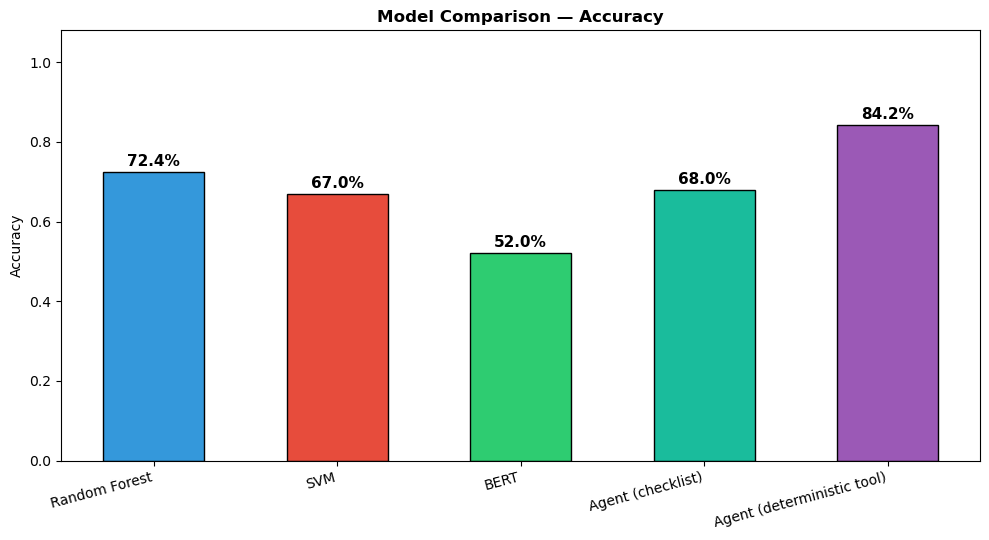

In [15]:
import matplotlib.pyplot as plt
colors = ['#3498DB', '#E74C3C', '#2ECC71', '#1ABC9C', '#9B59B6']
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(results.index, results['Accuracy'], color=colors, edgecolor='black', width=0.55)
for bar, v in zip(bars, results['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015, f'{v:.1%}', ha='center', fontweight='bold', fontsize=11)
ax.set_ylim(0, 1.08); ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison — Accuracy', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('final_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

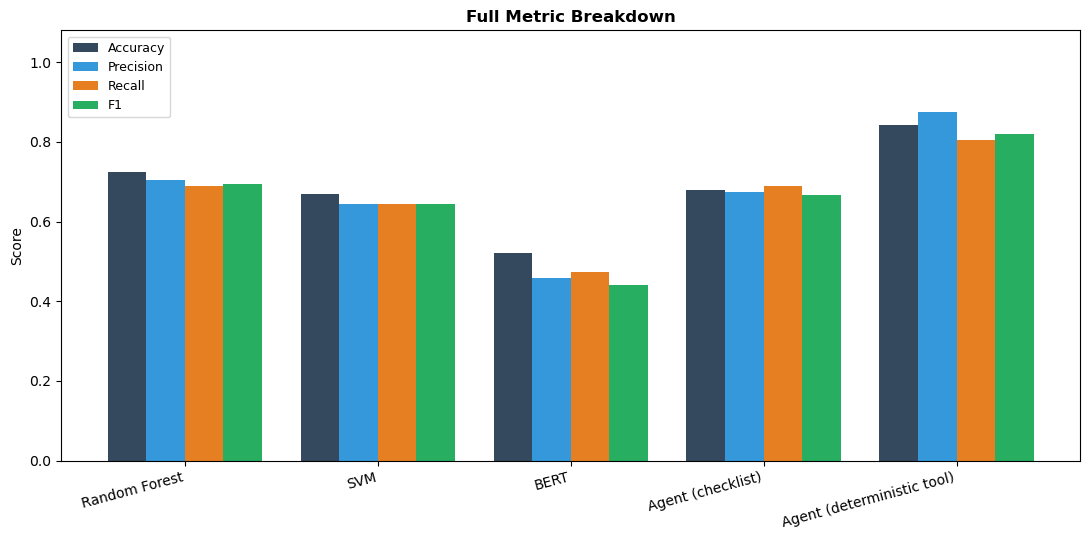

In [16]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x = range(len(results)); w = 0.2
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1']
mcolors = ['#34495E', '#3498DB', '#E67E22', '#27AE60']
for i, (m, c) in enumerate(zip(metrics_list, mcolors)):
    ax.bar([xi + (i - 1.5)*w for xi in x], results[m], w, label=m, color=c, edgecolor='none')
ax.set_xticks(list(x)); ax.set_xticklabels(results.index, fontsize=10, rotation=15, ha='right')
ax.set_ylim(0, 1.08); ax.set_ylabel('Score')
ax.set_title('Full Metric Breakdown', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('final_full.png', dpi=150, bbox_inches='tight')
plt.show()

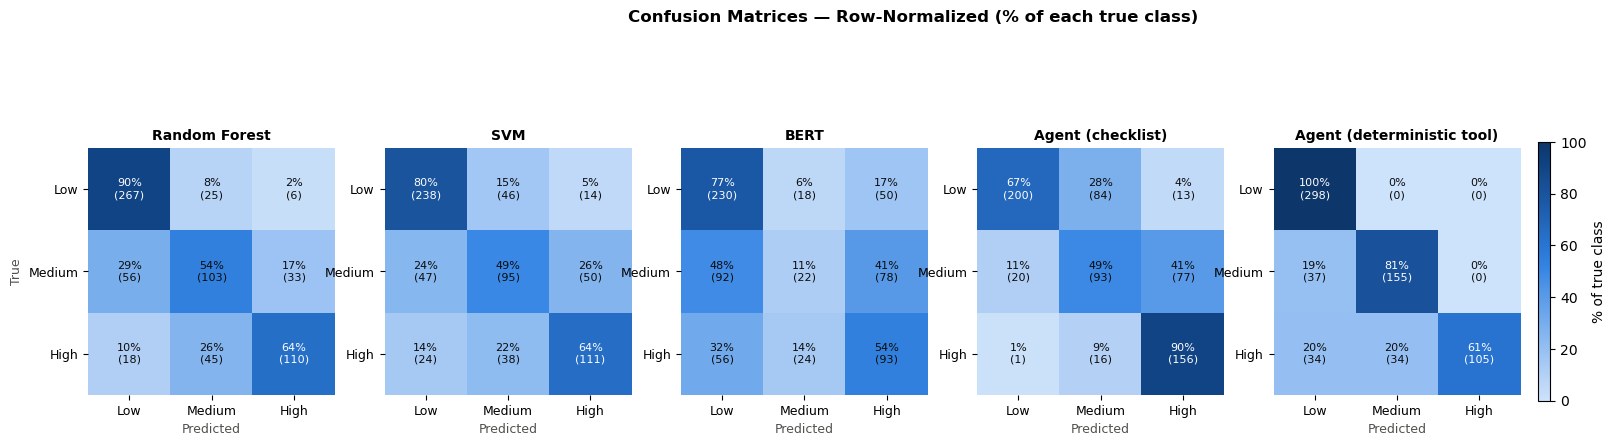

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.colors as mcolors

# Sequential blue ramp (dataviz palette, steps 100->700)
SEQ_BLUE = ['#cde2fb','#b7d3f6','#9ec5f4','#86b6ef','#6da7ec','#5598e7',
            '#3987e5','#2a78d6','#256abf','#1c5cab','#184f95','#104281','#0d366b']
cmap_blue = mcolors.LinearSegmentedColormap.from_list('seq_blue', SEQ_BLUE)

rf_pred_l = le_y.inverse_transform(rf.predict(X_te))
svm_pred_l = le_y.inverse_transform(svm.predict(X_te))
true_l_tabular = le_y.inverse_transform(y_te)

cm_inputs = [
    ('Random Forest', true_l_tabular, rf_pred_l),
    ('SVM', true_l_tabular, svm_pred_l),
    ('BERT', yt_l, pr_l),
    ('Agent (checklist)', checklist_valid['true_severity'], checklist_valid['pred_severity']),
    ('Agent (deterministic tool)', deterministic_df['true_severity'], deterministic_df['pred_severity']),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4.8))
im = None
for i, (ax, (name, yt, yp)) in enumerate(zip(axes, cm_inputs)):
    cm = confusion_matrix(yt, yp, labels=LABELS)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_pct = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0) * 100
    im = ax.imshow(cm_pct, cmap=cmap_blue, vmin=0, vmax=100)
    ax.set_xticks(range(3)); ax.set_xticklabels(LABELS, fontsize=9)
    ax.set_yticks(range(3)); ax.set_yticklabels(LABELS, fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9, color='#52514e')
    if i == 0:
        ax.set_ylabel('True', fontsize=9, color='#52514e')
    ax.set_title(name, fontweight='bold', fontsize=10)
    for r in range(3):
        for c in range(3):
            val = cm_pct[r, c]
            txt_color = 'white' if val > 55 else '#0b0b0b'
            ax.text(c, r, f'{val:.0f}%\n({cm[r, c]})', ha='center', va='center', fontsize=8, color=txt_color)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.colorbar(im, ax=axes, shrink=0.7, label='% of true class', pad=0.01)
fig.suptitle('Confusion Matrices — Row-Normalized (% of each true class)', fontweight='bold', y=1.04)
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
